In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("2) Stock Prices Data Set.csv")
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNon-positive prices:", (df[["open", "high", "low", "close"]] <= 0).sum().sum())

Shape: (497472, 7)

Data types:
 symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

Missing values:
 symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Duplicate rows: 0

Non-positive prices: 0


In [4]:
# Parse date properly instead of leaving it as a string
df["date"] = pd.to_datetime(df["date"])

# Drop rows with missing open/high/low (close and volume have none)
before = len(df)
df = df.dropna()
print(f"Dropped {before - len(df)} rows with missing values")

# Drop exact duplicate rows, if any
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# Drop rows with non-positive prices (data errors, not real trading days)
invalid = (df[["open", "high", "low", "close"]] <= 0).any(axis=1)
print(f"Dropping {invalid.sum()} rows with non-positive prices")
df = df[~invalid].reset_index(drop=True)

print("\nCleaned shape:", df.shape)

# Save the cleaned version for reuse in later tasks
df.to_csv("cleaned_stock_prices.csv", index=False)

Dropped 11 rows with missing values
Dropped 0 duplicate rows
Dropping 0 rows with non-positive prices

Cleaned shape: (497461, 7)


In [5]:
X = df[["open"]]   # predictor
y = df["close"]    # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (397968, 1)
Testing set: (99493, 1)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [7]:
print(f"Slope (coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nR-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Slope (coefficient): 0.9999
Intercept: 0.0267

R-squared: 0.9997
MSE: 2.7261
RMSE: 1.6511


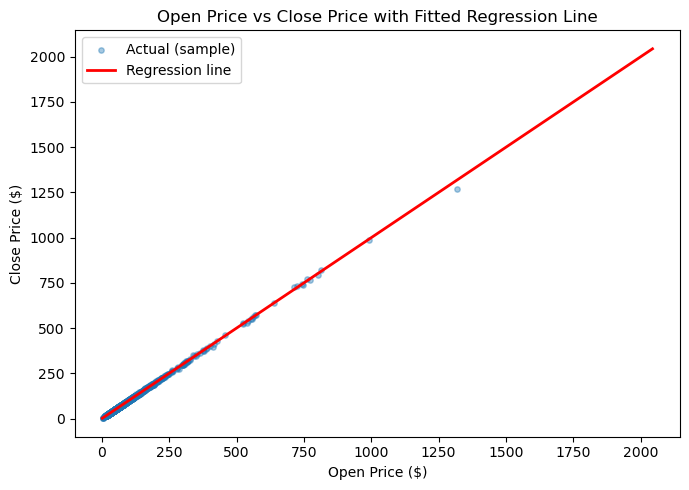

In [8]:
# Plotting all 497k points would be unreadable, so sample for the scatter
# (the model itself is trained on the full dataset, this is just for display)
sample = df.sample(2000, random_state=42)

x_line = pd.DataFrame({"open": np.linspace(df["open"].min(), df["open"].max(), 100)})
y_line = model.predict(x_line)

plt.figure(figsize=(7, 5))
plt.scatter(sample["open"], sample["close"], alpha=0.4, s=15, label="Actual (sample)")
plt.plot(x_line["open"], y_line, color="red", linewidth=2, label="Regression line")
plt.title("Open Price vs Close Price with Fitted Regression Line")
plt.xlabel("Open Price ($)")
plt.ylabel("Close Price ($)")
plt.legend()
plt.tight_layout()
plt.savefig("regression_open_vs_close.png", dpi=150)
plt.show()